In [1]:
import pandas as pd

import tubesml as tml

from source.report import report_points, report_victory, yearly_wrapper
from source.validate import random_split, yearly_split

from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('data/processed/men_training.csv')

df.head()

,Unnamed: 0,Season,DayNum,Team1,Team2,target,target_points,T1_Loc,T2_Loc,ID,...,delta_FT_perc,delta_FGM_no_ast_perc,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge
0,1,2003,136,1112,1436,1,29,0,0,2003_1112_1436,...,0.043580,-0.009639,0.029586,-0.024490,0.023279,-0.021080,0.500000,-15.0,15.296992,11.161959
1,2,2003,136,1113,1272,1,13,0,0,2003_1113_1272,...,0.016122,0.060936,0.023379,0.043313,0.017069,0.041206,1.000000,3.0,16.306520,6.912553
2,3,2003,136,1141,1166,1,6,0,0,2003_1141_1166,...,0.072864,-0.000726,0.024266,0.028571,0.001197,0.021989,-1.000000,5.0,17.037470,12.485948
3,4,2003,136,1143,1301,1,2,0,0,2003_1143_1301,...,-0.084846,0.017620,-0.027432,-0.019602,-0.010679,-0.002899,-0.666667,-1.0,4.086544,8.747367
4,5,2003,136,1140,1163,0,-5,0,0,2003_1140_1163,...,0.078796,-0.029044,0.028961,0.038428,0.005684,0.028207,-1.000000,7.0,13.738997,12.639235


* Both on target and target_points
* General 80/20 split, Kfold and test results
* kfold on n-1 season and test on the remaining one

In [3]:
df_train = df[['Season', 'target', 'target_points', 'ID', 'delta_Seed', 'delta_Score']]

df_train.head()

,Season,target,target_points,ID,delta_Seed,delta_Score
0,2003,1,29,2003_1112_1436,-15.0,17.421182
1,2003,1,13,2003_1113_1272,3.0,1.448276
2,2003,1,6,2003_1141_1166,5.0,0.102403
3,2003,1,2,2003_1143_1301,-1.0,2.082759
4,2003,0,-5,2003_1140_1163,7.0,-7.581720


In [4]:
pipe = Pipeline([('scl', tml.DfScaler()), ('ridge', Ridge())])

kfolds = KFold(n_splits=5, shuffle=True, random_state=345)

oof_pred, test_pred, result_dicts, train, y_train, test, y_test = random_split(df_train, pipe, kfolds, 'target_points', regression=True)

In [5]:
result_dicts["feat_imp"]

,mean,std
Feature,,
delta_Seed,-8.508479,0.031681
delta_Score,0.795537,0.054104


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


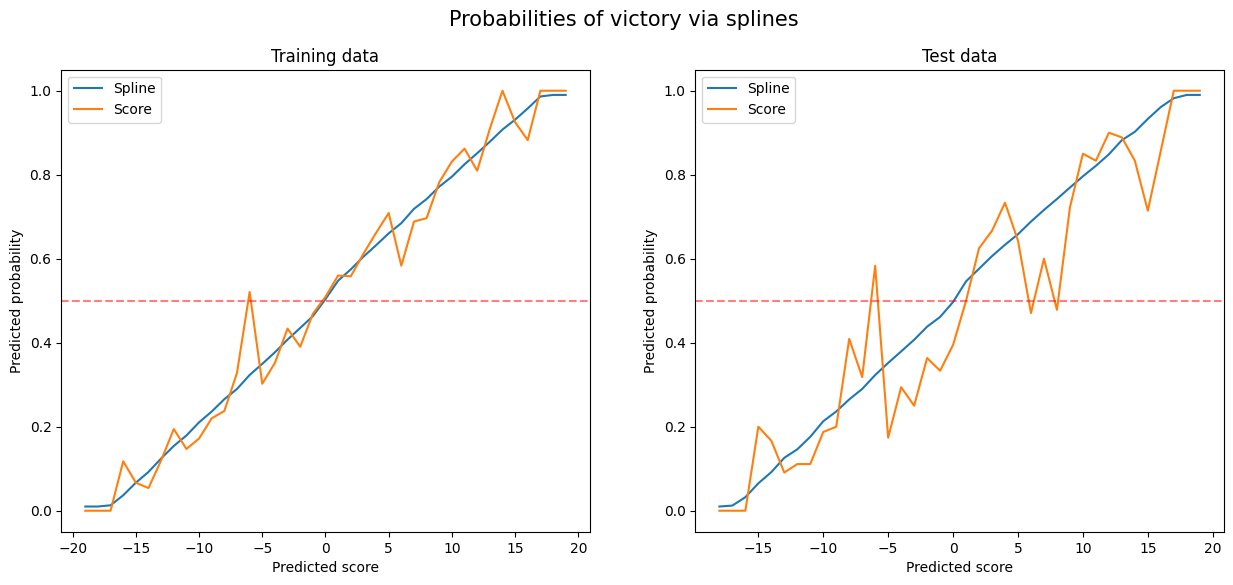

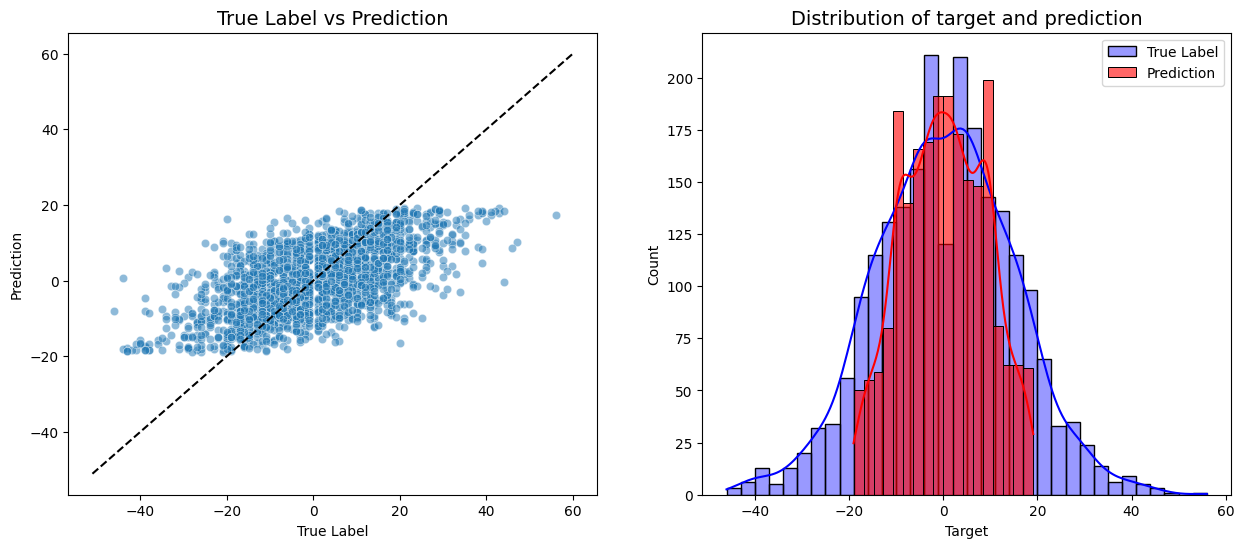

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


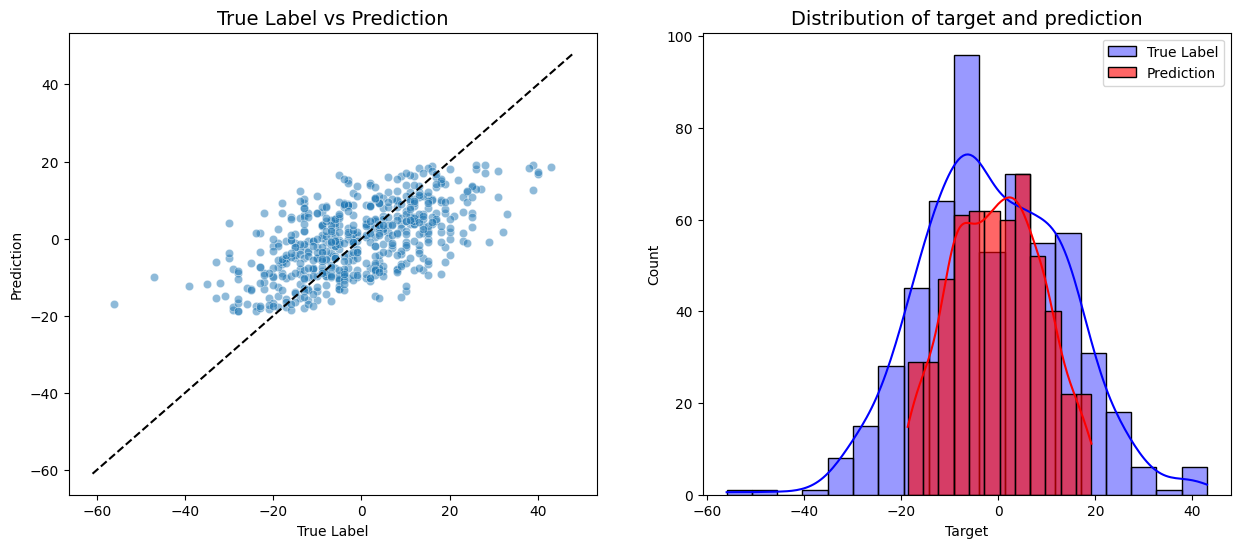

MAE train: 			 9.178
MAE test: 			 9.4048
RMSE train: 			 11.7487
RMSE test: 			 11.7372
Accuracy train: 		 0.7106
Accuracy test: 			 0.7194
Logloss train: 			 0.5506
Logloss test: 			 0.566
Brier train: 			 0.188
Brier test: 			 0.1939
Unsure train: 			 16.07%
Unsure test: 			 16.01%


,mae_oof,mae_test,mse_oof,mse_test,acc_oof,acc_test,logloss_oof,logloss_test,brier_oof,brier_test,unsure_oof,unsure_test
0,9.178,9.4048,11.7487,11.7372,0.7106,0.7194,0.5506,0.566,0.188,0.1939,16.07,16.01


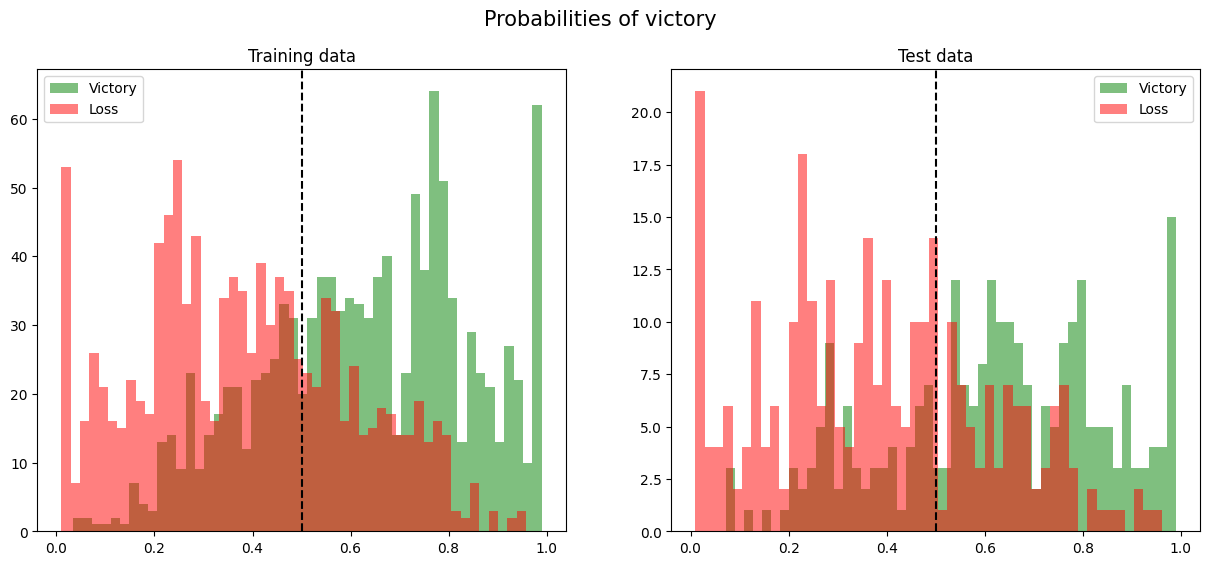

In [6]:
report_points(train, test, y_train, y_test, oof_pred, test_pred)

In [7]:
pipe = Pipeline([('scl', tml.DfScaler()),
                 ('logit', LogisticRegression(solver='lbfgs', multi_class='auto'))])

oof_pred, test_pred, result_dicts, train, y_train, test, y_test = random_split(df_train, pipe, kfolds, 'target', predict_proba=True)

In [8]:
result_dicts["feat_imp"]

,mean,std
Feature,,
delta_Seed,-1.184384,0.006848
delta_Score,0.131466,0.010728


Accuracy train: 		 0.7097
Accuracy test: 			 0.7176
Logloss train: 			 0.5555
Logloss test: 			 0.57
Brier train: 			 0.189
Brier test: 			 0.1947
Unsure train: 			 23.2673%
Unsure test: 			 20.5036%


,acc_oof,acc_test,logloss_oof,logloss_test,unsure_oof,unsure_test,brier_oof,brier_test
0,0.7097,0.7176,0.5555,0.57,23.2673,20.5036,0.189,0.1947


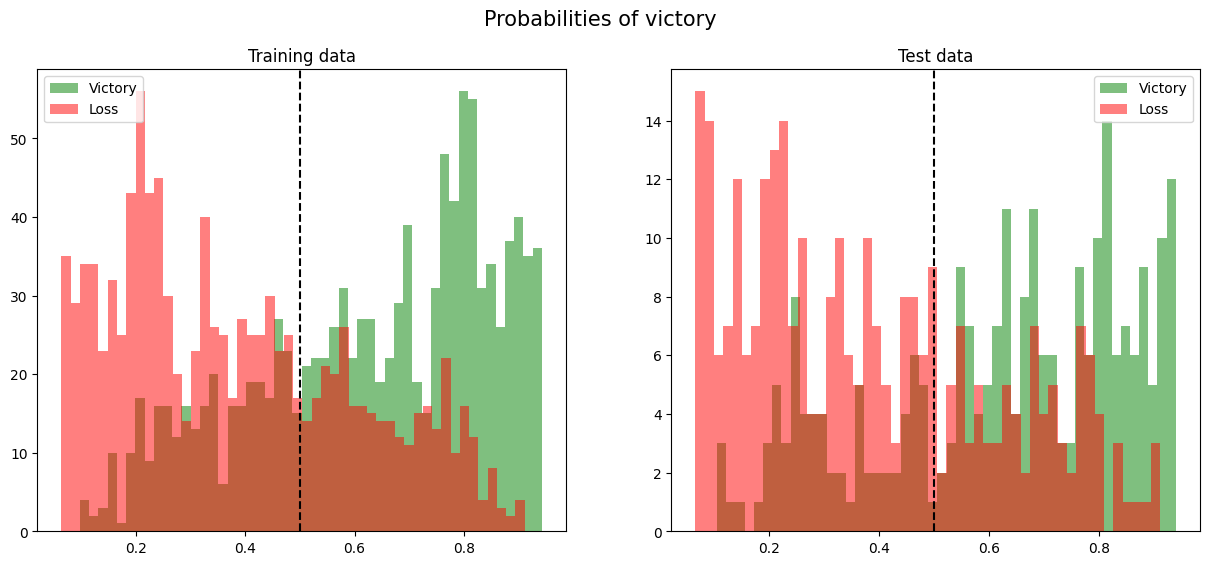

In [9]:
report_victory(y_train, y_test, oof_pred, test_pred)

In [10]:
pipe = Pipeline([('scl', tml.DfScaler()), ('ridge', Ridge())])

oof_preds, test_pred, result_dicts, train, y_train, test, y_test = yearly_split(df_train, pipe, kfolds, 'target_points')

In [11]:
result_dicts.keys()

dict_keys(['2022', '2023', '2024', '2025'])

2022


MAE train: 			 9.1667
MAE test: 			 10.5195
RMSE train: 			 11.6975
RMSE test: 			 12.9729
Accuracy train: 		 0.7134
Accuracy test: 			 0.6667
Logloss train: 			 0.5507
Logloss test: 			 0.6312
Brier train: 			 0.1881
Brier test: 			 0.2177
Unsure train: 			 16.06%
Unsure test: 			 11.11%


________________________________________


2023


MAE train: 			 9.2465
MAE test: 			 8.869
RMSE train: 			 11.777
RMSE test: 			 11.3377
Accuracy train: 		 0.7115
Accuracy test: 			 0.7143
Logloss train: 			 0.5517
Logloss test: 			 0.6104
Brier train: 			 0.1886
Brier test: 			 0.2051
Unsure train: 			 16.4%
Unsure test: 			 20.63%


________________________________________


2024


MAE train: 			 9.1568
MAE test: 			 10.8167
RMSE train: 			 11.6818
RMSE test: 			 13.2782
Accuracy train: 		 0.7138
Accuracy test: 			 0.6825
Logloss train: 			 0.5546
Logloss test: 			 0.5509
Brier train: 			 0.1894
Brier test: 			 0.1891
Unsure train: 			 17.31%
Unsure test: 			 15.87%


_____________________

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


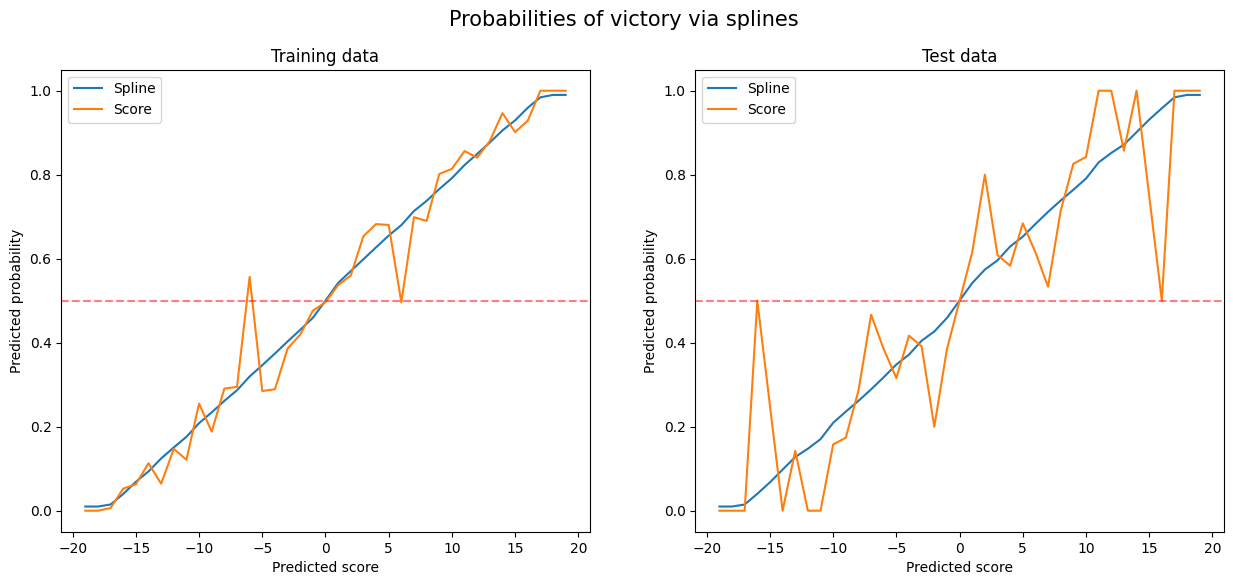

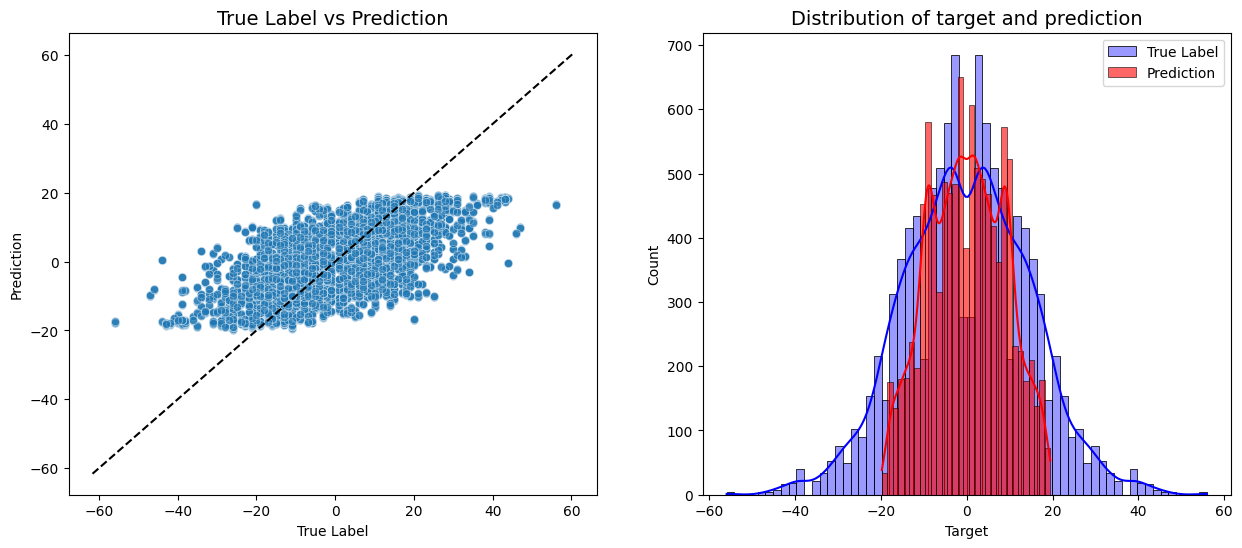

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


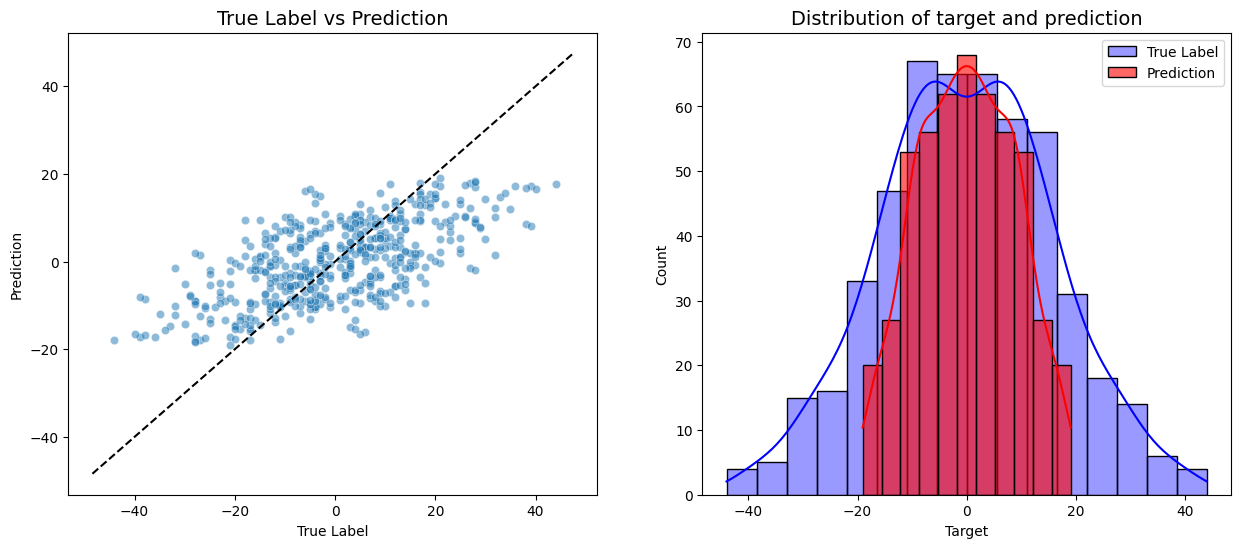

MAE train: 			 9.2028
MAE test: 			 9.8006
RMSE train: 			 11.7332
RMSE test: 			 12.2727
Accuracy train: 		 0.7113
Accuracy test: 			 0.7143
Logloss train: 			 0.5538
Logloss test: 			 0.5677
Brier train: 			 0.1892
Brier test: 			 0.1921
Unsure train: 			 16.6%
Unsure test: 			 16.67%


,mae_oof,mae_test,mse_oof,mse_test,acc_oof,acc_test,logloss_oof,logloss_test,brier_oof,brier_test,unsure_oof,unsure_test,year
0,9.1667,10.5195,11.6975,12.9729,0.7134,0.6667,0.5507,0.6312,0.1881,0.2177,16.06,11.11,2022
1,9.2465,8.8690,11.7770,11.3377,0.7115,0.7143,0.5517,0.6104,0.1886,0.2051,16.40,20.63,2023
2,9.1568,10.8167,11.6818,13.2782,0.7138,0.6825,0.5546,0.5509,0.1894,0.1891,17.31,15.87,2024
3,9.2411,8.9971,11.7763,11.3723,0.7063,0.7937,0.5580,0.4778,0.1909,0.1568,16.63,19.05,2025
4,9.2028,9.8006,11.7332,12.2727,0.7113,0.7143,0.5538,0.5677,0.1892,0.1921,16.60,16.67,total


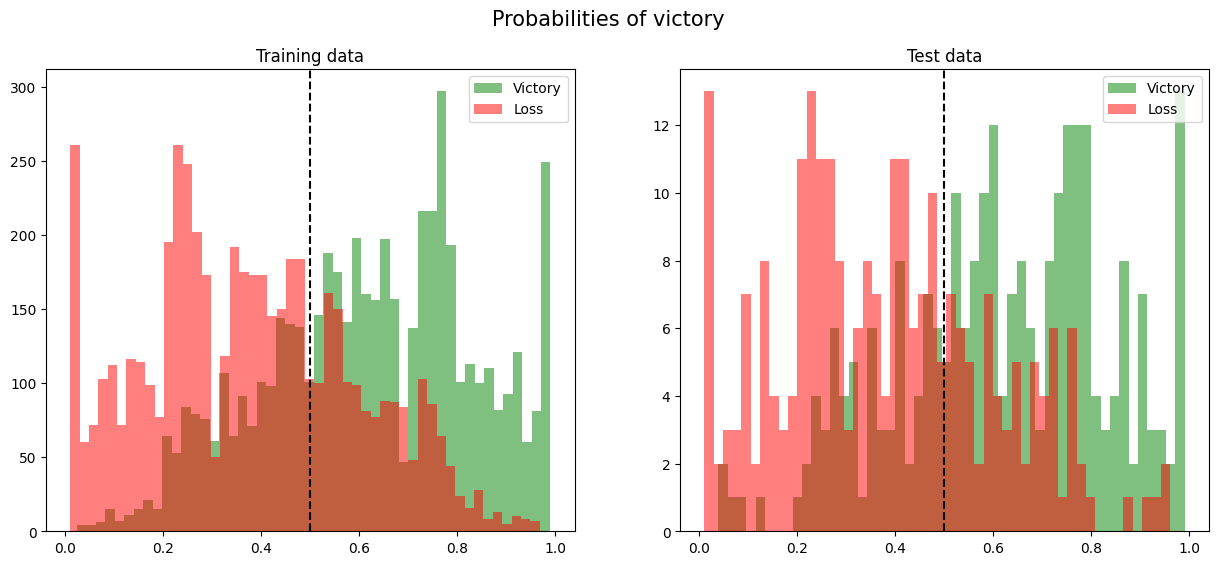

In [13]:
yearly_wrapper(train, test, y_train, y_test, oof_preds, test_pred)

In [15]:
pipe = Pipeline([('scl', tml.DfScaler()), ('logit', LogisticRegression(solver='lbfgs', multi_class='auto'))])

oof_preds, test_pred, result_dicts, train, y_train, test, y_test = yearly_split(df_train, pipe, kfolds, 'target', predict_proba=True)

2022


Accuracy train: 		 0.7123
Accuracy test: 			 0.6667
Logloss train: 			 0.5564
Logloss test: 			 0.632
Brier train: 			 0.1894
Brier test: 			 0.2195
Unsure train: 			 22.6621%
Unsure test: 			 15.873%


________________________________________


2023


Accuracy train: 		 0.7104
Accuracy test: 			 0.7143
Logloss train: 			 0.5576
Logloss test: 			 0.5967
Brier train: 			 0.1898
Brier test: 			 0.2035
Unsure train: 			 22.1719%
Unsure test: 			 20.6349%


________________________________________


2024


Accuracy train: 		 0.7119
Accuracy test: 			 0.6825
Logloss train: 			 0.5595
Logloss test: 			 0.5579
Brier train: 			 0.1904
Brier test: 			 0.1905
Unsure train: 			 22.4736%
Unsure test: 			 22.2222%


________________________________________


2025


Accuracy train: 		 0.7081
Accuracy test: 			 0.7937
Logloss train: 			 0.5636
Logloss test: 			 0.4772
Brier train: 			 0.1922
Brier test: 			 0.1546
Unsure train: 			 22.813%
Unsure test: 			 28.5714%


__________________________

,acc_oof,acc_test,logloss_oof,logloss_test,unsure_oof,unsure_test,brier_oof,brier_test,year
0,0.7123,0.6667,0.5564,0.6320,22.6621,15.8730,0.1894,0.2195,2022
1,0.7104,0.7143,0.5576,0.5967,22.1719,20.6349,0.1898,0.2035,2023
2,0.7119,0.6825,0.5595,0.5579,22.4736,22.2222,0.1904,0.1905,2024
3,0.7081,0.7937,0.5636,0.4772,22.8130,28.5714,0.1922,0.1546,2025
4,0.7107,0.7143,0.5593,0.5660,22.5302,21.8254,0.1905,0.1920,total


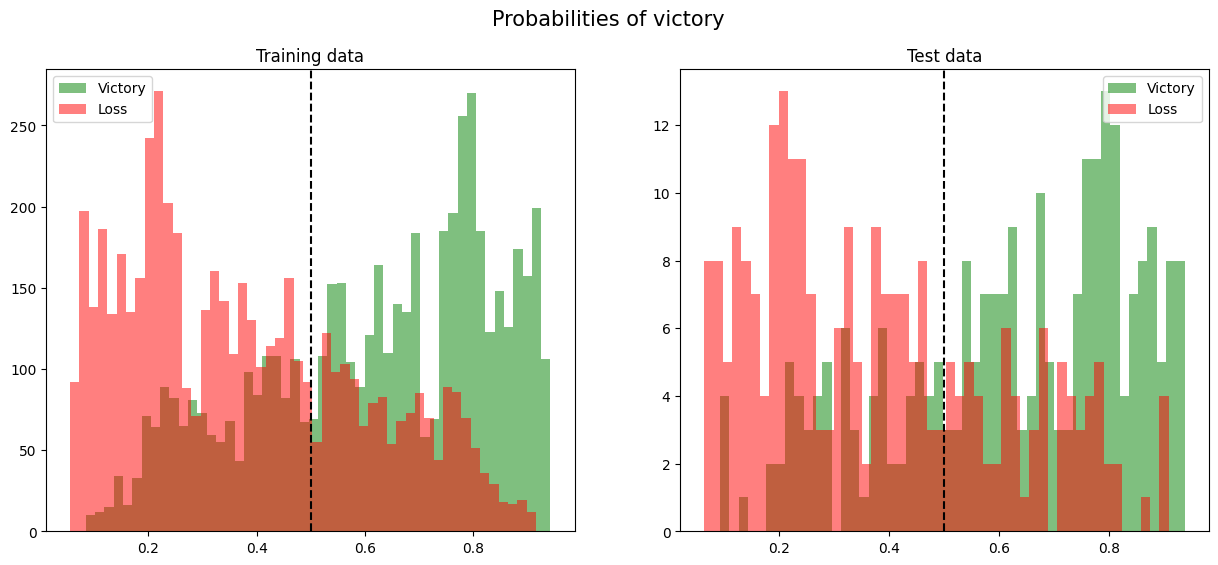

In [17]:
yearly_wrapper(train, test, y_train, y_test, oof_preds, test_pred, points=False)